In [1]:
import itertools

import numpy as np
import scipy as sp
import networkx as nx


import igl

import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from src import shapes, vis

# Functions on Boundaries

Boundaries should be represented as graph $G = (V, E)$, embeded into 3-dimensional space ($\phi: V\to\mathbb{R}^3$).
We aim to define the function $f\to \mathbb{R}$ such that if the vertex degree is not 2, this vertex is local maximum or local minimum.
Let's try to define an eigen function of double derivative with this constarins.

The first we need to define an orientation on each chain or cycle $v_0^i, v_1^i, ..., v_{n - 1}^i \in C_i\subset V$, $\deg(v_j^i) = 2$. If $C_i$ is a cycle, then $v_n := v_0$.

Let's define a derivative function
$$
\delta f (v_j^i) = 
\begin{cases}
\frac{f(v_{j + 1}^i) - f(v_{j}^i)}{2\cdot||\phi(v_{j+1}) - \phi(v_j)||} + \frac{f(v_{j}^i) - f(v_{j - 1}^i)}{2\cdot||\phi(v_{j}) - \phi(v_{j - 1})||},  & \text{if}\; \deg(v_j) = 2 \\
0, & \text{if}\; \deg(v_j) \ne 2
\end{cases}
$$

and so double derivative
$$
\delta^2 f (v_j^i) = 
\begin{cases}
\frac{\delta f(v_{j + 1}^i) - \delta f(v_{j}^i)}{2\cdot||\phi(v_{j+1}) - \phi(v_j)||} + \frac{\delta f(v_{j}^i) - \delta f(v_{j - 1}^i)}{2\cdot||\phi(v_{j}) - \phi(v_{j - 1})||},  & \text{if}\; \deg(v_j) = 2 \\
0, & \text{if}\; \deg(v_j) \ne 2
\end{cases}
$$

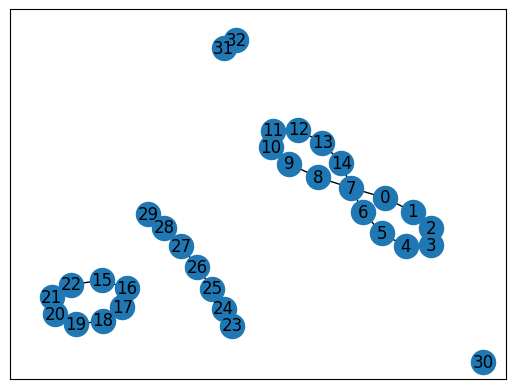

In [2]:
graph = nx.Graph()
graph.add_nodes_from(range(31))

graph.add_edges_from(np.transpose([np.arange(8), np.arange(1, 9)])%8)
graph.add_edges_from(np.transpose([np.arange(7), np.arange(1, 8)])%8 + 7)
graph.add_edges_from([(7, 14)])
graph.add_edges_from(np.transpose([np.arange(8), np.arange(1, 9)])%8 + 15)
graph.add_edges_from(np.transpose([np.arange(6), np.arange(1, 7)]) + 23)
graph.add_edge(31, 32)

pos = nx.spring_layout(graph)
pos = {node: 10*p for node, p in pos.items()}

nx.draw_networkx(graph, pos=pos)

In [3]:
import networkx as nx


def get_chains(graph: nx.Graph, similar_start_end_of_cycle=False):
    """
    Returns the list of all chains of the graph.

    A chain is a maximal path whose internal nodes have degree 2
    (endpoints have degree != 2), or (if a connected component is a
    pure cycle where all nodes have degree 2) the whole cycle as one chain.

    Returns
    -------
    list[list[Hashable]]
        Each chain is returned as an ordered list of nodes.
        For cycle-components, the chain is a cyclic order with the first node
        repeated at the end to make the cycle explicit.
    """
    G = graph

    # Degree in a MultiGraph can be >2 because of parallel edges; this function assumes simple graphs,
    # but we still use G.degree(v) which NetworkX defines for any graph.
    deg = dict(G.degree())

    visited_undirected_edges = set()  # store edges as (min(u,v), max(u,v))

    def mark_edge(u, v):
        a, b = (u, v) if u <= v else (v, u)
        visited_undirected_edges.add((a, b))

    def edge_marked(u, v):
        a, b = (u, v) if u <= v else (v, u)
        return (a, b) in visited_undirected_edges

    chains = []

    # 1) Build chains starting from "junctions" / endpoints: nodes with degree != 2
    for start in G.nodes:
        if deg[start] == 2:
            continue

        for nbr in G.neighbors(start):
            if edge_marked(start, nbr):
                continue

            chain = [start]
            prev = start
            cur = nbr
            mark_edge(prev, cur)

            # Walk forward while we're in degree-2 nodes (internal chain nodes)
            while True:
                chain.append(cur)

                if deg[cur] != 2:
                    # We hit a terminal/junction node: chain ends here.
                    break

                # Choose the next neighbor that isn't the previous node
                nbs = list(G.neighbors(cur))
                # In a simple graph with deg==2, there are exactly 2 neighbors.
                nxt = nbs[0] if nbs[0] != prev else nbs[1]

                if edge_marked(cur, nxt):
                    # We've already consumed this edge; stop to avoid duplicates.
                    break

                prev, cur = cur, nxt
                mark_edge(prev, cur)

            chains.append(chain)

    # 2) Remaining edges (if any) belong to components where all nodes have degree 2 => cycles.
    # We treat each such component as one chain (cycle order).
    for comp in nx.connected_components(G):
        comp_nodes = list(comp)
        if not comp_nodes:
            continue
        if any(deg[v] != 2 for v in comp_nodes):
            continue  # not a pure cycle component

        # If all edges in this component are already visited, skip.
        comp_edges = list(G.subgraph(comp_nodes).edges())
        if all(edge_marked(u, v) for (u, v) in comp_edges):
            continue

        # Build an explicit cyclic order by walking until we return to start.
        start = comp_nodes[0]
        nbrs = list(G.neighbors(start))
        if len(nbrs) != 2:
            # Shouldn't happen in a pure cycle, but be defensive.
            continue

        chain = [start]
        prev = start
        cur = nbrs[0]
        mark_edge(prev, cur)

        while True:
            chain.append(cur)
            if cur == start:
                break

            nbs = list(G.neighbors(cur))
            nxt = nbs[0] if nbs[0] != prev else nbs[1]

            # If we're about to close, allow it; otherwise avoid reusing visited edges.
            if edge_marked(cur, nxt) and nxt != start:
                break

            prev, cur = cur, nxt
            mark_edge(prev, cur)

            if cur == start:
                chain.append(start)
                break

        # Ensure it's a cycle representation: end equals start.
        if chain[-1] != start:
            chain.append(start)

        chains.append(chain)

    if not similar_start_end_of_cycle:
        for i, chain in enumerate(chains):
            if chain[0] == chain[-1]:
                chains[i] = chain[:-1]
    chains = [np.array(chain) for chain in chains]

    return chains

In [4]:
for chain in get_chains(graph):
    print(chain)

[7 6 5 4 3 2 1 0]
[ 7  8  9 10 11 12 13 14]
[23 24 25 26 27 28 29]
[31 32]
[15 16 17 18 19 20 21 22]


In [5]:
def get_derivative_operator(graph, pos):
    """
    """
    nodes_indices = {node: i for i, node in enumerate(graph.nodes())}

    matrix = np.zeros(shape=(graph.number_of_nodes(), graph.number_of_nodes()))
    for chain in get_chains(graph, similar_start_end_of_cycle=False):
        for inode, node in enumerate(chain):
            if graph.degree(node) == 2:
                v0, v1, v2 = chain[np.array([inode - 1, inode, inode + 1])%len(chain)]
                i0, i1, i2 = [nodes_indices[v] for v in (v0, v1, v2)]
                p0, p1, p2 = [pos[v] for v in (v0, v1, v2)]
                d01 = np.linalg.norm(p1 - p0)
                d12 = np.linalg.norm(p2 - p1)
                matrix[i1, i0] += 0.5/d01
                matrix[i1, i1] += 0.5/d01 + 0.5/d12
                matrix[i1, i2] += 0.5/d12
                

    return matrix

In [6]:
def get_derivative_operator(graph, pos):
    """
    """
    nodes_indices = {node: i for i, node in enumerate(graph.nodes())}

    matrix = np.zeros(shape=(graph.number_of_nodes(), graph.number_of_nodes()))
    for chain in get_chains(graph, similar_start_end_of_cycle=True):
        for v0, v1 in itertools.pairwise(chain):
            i0, i1 = [nodes_indices[v] for v in (v0, v1)]
            p0, p1 = [pos[v] for v in (v0, v1)]
            matrix[i0, i1] += 0.5/np.linalg.norm(p1 - p0)
            matrix[i1, i0] -= 0.5/np.linalg.norm(p1 - p0)

    return matrix

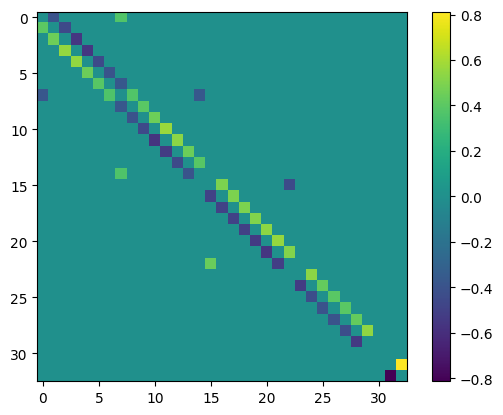

In [7]:
md1 = get_derivative_operator(graph, pos)

plt.colorbar(plt.imshow(md1))

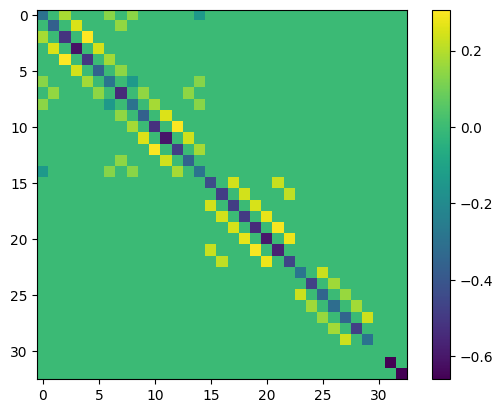

In [8]:
md2 = md1@md1

plt.colorbar(plt.imshow(md2))

In [9]:
md1[[i for i, node in enumerate(graph.nodes) if graph.degree(node) != 2]].shape

(6, 33)

In [10]:
vals, vecs = np.linalg.eig(md2)

In [11]:
import numpy as np

def constrained_real_eig(A, C, assume_symmetric=True, rtol=1e-12, imag_tol=1e-10):
    """
    Solve Ax = λx subject to Cx = 0, returning only (approximately) real eigenpairs.

    Parameters
    ----------
    A : (n,n) array_like
    C : (m,n) array_like
    assume_symmetric : bool
        If True, solves the symmetric reduced problem with eigh (guarantees real output
        when A is symmetric). If False, uses eig and filters real modes.
    rtol : float
        Nullspace tolerance
    imag_tol : float
        Keep eigenpairs whose imaginary part magnitude <= imag_tol

    Returns
    -------
    vals_real : (k,) ndarray
    vecs_real : (n,k) ndarray
        Columns are real constrained eigenvectors
    """
    A = np.asarray(A, dtype=float)
    C = np.asarray(C, dtype=float)

    # Nullspace basis N for Cx=0 using SVD
    U, S, Vt = np.linalg.svd(C, full_matrices=True)
    if S.size == 0:
        N = np.eye(A.shape[0])
    else:
        rank = (S > rtol * S[0]).sum()
        N = Vt[rank:].T

    if N.size == 0:
        raise ValueError("Constraint eliminates entire space")

    A_red = N.T @ A @ N

    if assume_symmetric:
        # Best case: real eigenpairs (if A is truly symmetric)
        vals, vecs_red = np.linalg.eigh(A_red)
        vecs = N @ vecs_red
        vecs = np.real_if_close(vecs, tol=1000)
        vals = np.real_if_close(vals, tol=1000)
        vecs = np.asarray(vecs, dtype=float)
        vals = np.asarray(vals, dtype=float)
    else:
        # General case: may be complex; filter near-real eigenpairs
        vals, vecs_red = np.linalg.eig(A_red)
        keep = (np.abs(np.imag(vals)) <= imag_tol)
        vals = vals[keep]
        vecs_red = vecs_red[:, keep]
        vecs = N @ vecs_red

        # keep only vectors that are also near-real
        keep_vec = (np.max(np.abs(np.imag(vecs)), axis=0) <= imag_tol)
        vals = np.real(vals[keep_vec])
        vecs = np.real(vecs[:, keep_vec])

    # Normalize
    norms = np.linalg.norm(vecs, axis=0, keepdims=True)
    vecs = vecs / np.where(norms == 0, 1.0, norms)

    return vals, vecs

In [12]:
def get_eigen_values_for_graph(graph, pos, with_vals=True):
    """
    """
    md1 = get_derivative_operator(graph, pos)
    md2 = md1@md1
    vals, vecs = constrained_real_eig(md2, md1[[i for i, node in enumerate(graph.nodes) if graph.degree(node) != 2]])
    
    return vals, vecs

In [13]:
vals, vecs = get_eigen_values_for_graph(graph, pos)

vecs.shape

(33, 28)

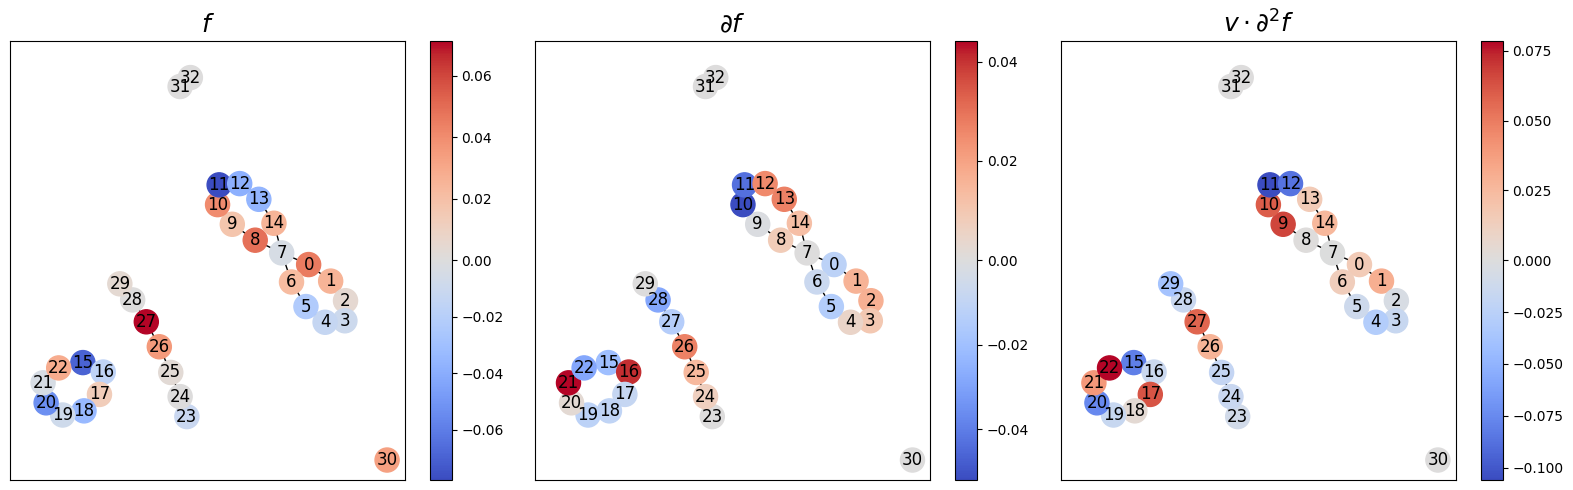

In [14]:
values0 = vecs.mean(axis=1)
values1 = md1 @ values0
values2 = md2 @ values0
values3 = md2 @ values0 / vals.mean()

val_list = [values0, 
            values1, 
            #values2, 
            values3]
titles = ['$f$', 
          r'$\partial f$', 
          #r'$\partial^2 f$', 
          r'$v\cdot\partial^2 f$']

cmap = plt.get_cmap("managua")
cmap = plt.get_cmap('coolwarm')


fig, axs = plt.subplots(1, len(val_list), figsize=(5*len(val_list) + 1, 5))

for i, (val, title) in  enumerate(zip(val_list, titles)):

    axs[i].set_title(title, fontsize=18)
    norm = mcolors.TwoSlopeNorm(vmin=val.min(), vcenter=0, vmax=val.max())
    nx.draw_networkx(graph, pos=pos, node_color=cmap(norm(val)), ax=axs[i])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig.colorbar(sm, ax=axs[i])   # or plt.colorbar(sm, ax=ax)

plt.tight_layout()
plt.show()

# For the 2d complex

# Generate a Complex

In [15]:
def diffeo(vertices, a=0.2, b=1.1, c=0.2, d=1.2, e=0.2, f=0.3):
    v = vertices.copy()
    x, y, z = v[:, 0], v[:, 1], v[:, 2]

    v[:, 0] = x + a*np.sin(b*y) + c*np.sin(d*z)
    v[:, 1] = y + e*np.sin(f*x)

    return v

def cylindrical_twist(vertices, k=0.2, mode="x", scale=0.5):
    """
    Nonlinear cylindrical twist diffeomorphism on R^3.

    vertices: (n,3) array
    mode:
      - "z": angle depends on z  (theta = k * tanh(z/scale))
      - "r": angle depends on radius r (theta = k * tanh(r/scale))
    k: twist strength (radians, roughly bounded by +/-k for tanh)
    scale: controls how quickly tanh saturates
    """
    if mode == 'x':
        v = vertices[:, [1, 2, 0]]
        v = cylindrical_twist(v, k=k, mode="z", scale=scale)
        v = v[:, [2, 0, 1]]
        return v
        
    v = vertices.copy()
    x, y, z = v[:, 0], v[:, 1], v[:, 2]

    r = np.sqrt(x*x + y*y)

    if mode == "z":
        theta = k * np.tanh(z / scale)
    elif mode == "r":
        theta = k * np.tanh(r / scale)
    else:
        raise ValueError('mode must be "z" or "r"')

    c, s = np.cos(theta), np.sin(theta)

    v[:, 0] = c * x - s * y
    v[:, 1] = s * x + c * y
    # z unchanged
    return v

In [16]:
n, m = 17, 16
vertices0, faces0 = shapes.get_halftori_bouquet(leaves=3, n=n, m=m, l0=1.0, glue=True)
#vertices3, faces3 = shapes.get_halftori_bouquet(leaves=2, n=n, m=m, l0=0.6, glue=False)

n0, n1 = 12, 12
r0, r1 = 0.8, 0.6
vertices1, faces1 = shapes.get_couple_linked_tori(n0=n0, n1=n1, r0=r0, r1=r1)

vertices0 += np.array([vertices0[:, 0].min(), 0, 0])
vertices1 += np.array([vertices1[:, 0].max(), 0, 0])

vertices, faces, _ = shapes.merge_meshes_with_weld(vertices0, faces0, vertices1, faces1)
vertices, faces = shapes.split_large_edges(vertices, faces, max_length=0.8)

vertices = cylindrical_twist(vertices, mode='x', scale=1.0, k=0.4)

In [17]:
mesh = vis.get_pv_mesh(vertices, faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, smooth_shading=False, show_edges=True, opacity=0.6)
pl.show()

Widget(value='<iframe src="http://localhost:37683/index.html?ui=P_0x7676effeffe0_0&reconnect=auto" class="pyvi…

## Detect a boundary

In [18]:
class NM:
    def __init__(self, faces, vertices):
        self.faces = np.unique(np.sort(faces, axis=1), axis=0)
        self.vertices = np.array(vertices)

    def get_boundary_edges(self):
        """
        """
        face_edges = np.concatenate([self.faces[:, j] for j in [[0, 1], [0, 2], [1, 2]]])
        face_edges = np.sort(face_edges, axis=1)
        edges = np.unique(face_edges, axis=0)
        edges = edges[(edges[:, None, :] == face_edges).all(axis=-1).sum(axis=-1) != 2]
        return edges

    def get_conic_vertices(self):
        """
        """
        conic_vertices = []
        for vertex in np.unique(self.faces):
            faces_vertex = faces[(faces == vertex).any(axis=1)]
            connections = faces_vertex[:, None, :, None] == faces_vertex[None, :, None, :]
            connections = connections.any(axis=-1).sum(axis=-1) == 2
            n_components, _ = sp.sparse.csgraph.connected_components(connections, directed=False)
            if n_components > 1:
                conic_vertices.append(vertex)
        conic_vertices = np.array(conic_vertices)
        return conic_vertices

    def get_boundary_graph(self, with_boundary_edges: bool=True, with_conic_vertices: bool=True):
        """
        """
        graph = nx.Graph()
        if with_boundary_edges:
            graph.add_edges_from(self.get_boundary_edges())
        if with_conic_vertices:
            graph.add_nodes_from(self.get_conic_vertices())


        return graph

In [19]:
nm = NM(faces, vertices)
boundary_graph = nm.get_boundary_graph()
boundary_graph_pos = {node: nm.vertices[node] for node in boundary_graph.nodes}

In [20]:
vals, vecs = get_eigen_values_for_graph(boundary_graph, boundary_graph_pos)
vecs.shape

(86, 83)

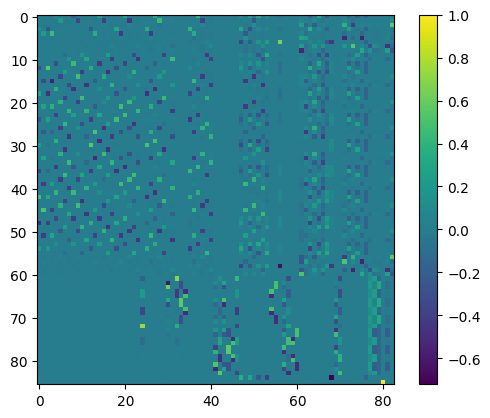

In [21]:
plt.colorbar(plt.imshow(vecs))

In [91]:
vec_val = vecs.sum(axis=1)
vec_val = vecs[np.argmax(abs(vals))]

md1 = get_derivative_operator(boundary_graph, boundary_graph_pos)
vec_diff = md1@vec_val

norm_val = mcolors.TwoSlopeNorm(vmin=vec_val.min(), vcenter=0, vmax=abs(vec_val).max())
norm_diff = mcolors.TwoSlopeNorm(vmin=vec_val.min(), vcenter=0, vmax=abs(vec_val).max())


node_colors_val = [c for c in plt.get_cmap('coolwarm')(norm_val(vec_val))]
node_colors_diff = [c for c in plt.get_cmap('coolwarm')(norm_diff(vec_diff))]

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 83 is different from 86)

In [92]:
pl = pv.Plotter(shape=(1, 2), window_size=(1000, 600))

pl.subplot(0, 0)
pl.add_text('f')
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.3)
vis.add_graph_to_plotter(pl, boundary_graph, boundary_graph_pos, node_color=node_colors_val, edge_color='black', edge_width=2, node_size=10)

pl.subplot(0, 1)
pl.add_text('df')
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.3)
vis.add_graph_to_plotter(pl, boundary_graph, boundary_graph_pos, node_color=node_colors_diff, edge_color='black', edge_width=2, node_size=10)


pl.link_views()
pl.show()

Widget(value='<iframe src="http://localhost:37683/index.html?ui=P_0x76759c27c680_14&reconnect=auto" class="pyv…